# Twelve-month PD model

The target is first default within the next 12 months. The primary model is logistic regression.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

Development

Data: surviving loan-month observations with a complete 12-month outcome window.

Features: borrower quality, leverage, delinquency history, modification, balance, rate and loan type.

Split: chronological development, calibration and out-of-time periods.

Method: imputation, standardisation, one-hot encoding, logistic regression and odds calibration.

Tests: ROC-AUC, Gini, KS, Brier score and observed versus predicted rates.

In [2]:
metrics = query("select * from pd_model_metrics where model='12-month logistic PD'"); metrics

,model,sample,rows,defaults,roc_auc,gini,ks,brier_score,observed_rate,predicted_rate
0,12-month logistic PD,development,871009,6876,0.8272,0.6545,0.4906,0.0072,0.0079,0.0022
1,12-month logistic PD,out_of_time,43914,181,0.7192,0.4384,0.3800,0.0038,0.0041,0.0036


In [3]:
pd_data = query("select * from pd_development_sample where target_name='12_month_pd'")
numeric = ['classic_fico','original_dti','original_ltv','current_ltv','current_dpd','max_dpd_3m','max_dpd_6m','max_dpd_12m','current_actual_upb','current_interest_rate','modification_history','unemployment_rate','gdp_growth_yoy','hpi_growth_yoy']
categorical = ['occupancy_status','loan_purpose','property_type']
features = numeric + categorical
prepare = ColumnTransformer([
    ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')),('scale', StandardScaler())]), numeric),
    ('categorical', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical)
])
notebook_pd = Pipeline([('prepare', prepare),('model', LogisticRegression(max_iter=500, C=.5))])
development = pd_data[pd_data.split.eq('development')]
notebook_pd.fit(development[features], development.target, model__sample_weight=development.observation_weight)
rows = []
for name in ['development','out_of_time']:
    data = pd_data[pd_data.split.eq(name)]
    probability = notebook_pd.predict_proba(data[features])[:,1]
    rows.append({'sample':name,'rows':len(data),'defaults':int(data.target.sum()),
                 'weighted_auc':roc_auc_score(data.target, probability, sample_weight=data.observation_weight),
                 'weighted_brier':brier_score_loss(data.target, probability, sample_weight=data.observation_weight)})
pd.DataFrame(rows)

,sample,rows,defaults,weighted_auc,weighted_brier
0,development,75636,6876,0.8272,0.0070
1,out_of_time,2181,181,0.7177,0.0044


In [4]:
coefficients = query("select * from pd_model_coefficients where model='12-month PD'")
coefficients.reindex(coefficients.coefficient.abs().sort_values(ascending=False).index).head(15)

,model,feature,coefficient
0,12-month PD,categorical__occupancy_status_I,-1.0509
1,12-month PD,categorical__loan_purpose_P,-1.0088
2,12-month PD,categorical__loan_purpose_N,-0.9320
3,12-month PD,categorical__occupancy_status_S,-0.9173
4,12-month PD,categorical__property_type_CO,-0.9034
5,12-month PD,categorical__property_type_SF,-0.8869
6,12-month PD,categorical__property_type_PU,-0.8558
7,12-month PD,categorical__loan_purpose_C,-0.8162
8,12-month PD,categorical__occupancy_status_P,-0.7888
24,12-month PD,numeric__original_ltv,0.5432


In [5]:
calibration = query("select * from pd_calibration where model='12-month logistic PD'")
calibration[['band','observations','defaults','observed_rate','predicted_rate','calibration_ratio']]

,band,observations,defaults,observed_rate,predicted_rate,calibration_ratio
0,"(-0.0009103000000000001, 0.000704]",4392,6.0000,0.0014,0.0005,0.3723
1,"(0.000704, 0.000982]",4391,20.0000,0.0046,0.0008,0.1859
2,"(0.000982, 0.00126]",4391,2.0000,0.0005,0.0011,2.4635
3,"(0.00126, 0.00156]",4392,8.0000,0.0018,0.0014,0.7719
4,"(0.00156, 0.00189]",4391,1.0000,0.0002,0.0017,7.5547
5,"(0.00189, 0.00231]",4391,4.0000,0.0009,0.0021,2.2993
6,"(0.00231, 0.00284]",4392,25.0000,0.0057,0.0026,0.4498
7,"(0.00284, 0.00358]",4391,29.0000,0.0066,0.0032,0.4820
8,"(0.00358, 0.00513]",4391,22.0000,0.0050,0.0042,0.8451
9,"(0.00513, 0.841]",4392,64.0000,0.0146,0.0187,1.2823


Text(0.5, 1.0, 'Out-of-time calibration')

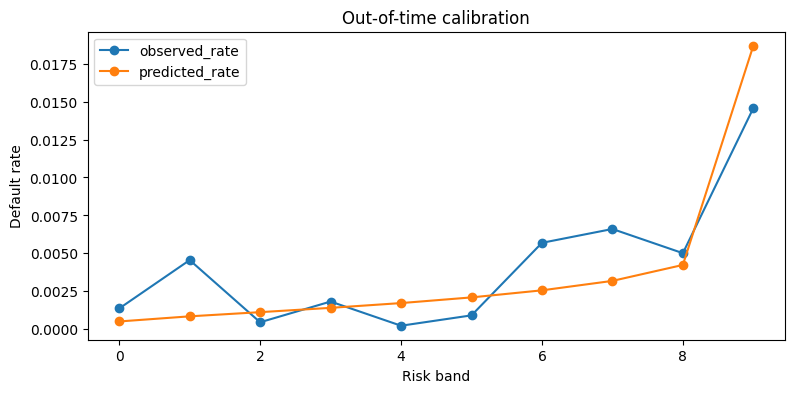

In [6]:
plot_data = calibration.reset_index(drop=True)
ax = plot_data[['observed_rate','predicted_rate']].plot(marker='o')
ax.set_xlabel('Risk band'); ax.set_ylabel('Default rate'); ax.set_title('Out-of-time calibration')

Output: current and origination 12-month PD estimates used in SICR and hazard calibration.